# Download models & package

In [15]:
!pip install torch -f https://download.pytorch.org/whl/torch_stable.html.

Looking in links: https://download.pytorch.org/whl/torch_stable.html.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\sslin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
!pip install tqdm

In [52]:
!pip install nbeats-pytorch

   ---------------------------------------- 903.8/903.8 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-tools 1.62.1 requires protobuf<5.0dev,>=4.21.6, but you have protobuf 3.20.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\sslin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
!pip install lightning


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\sslin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [61]:
!python -m pip install prophet

In [118]:
!pip install pytorch-tcn


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\sslin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\sslin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Load Dataset

In [3]:
with open('NASA_access_log_Aug95.txt', 'rb') as f:
    file_content_Aug = f.read().decode('latin-1')

with open('NASA_access_log_Jul95.txt', 'rb') as f:
    file_content_Jul = f.read().decode('latin-1')

In [4]:
print("Jul length", len(file_content_Jul))
print("Aug length", len(file_content_Aug))
print("total", len(file_content_Aug)+len(file_content_Jul))

Jul length 205242368
Aug length 167813770
total 373056138


In [5]:
"""
request format: host, timestamp ["DAY MON DD HH:MM:SS YYYY"], HTTP reply code, bytes in the reply.
ex. in24.inetnebr.com - - [01/Aug/1995:00:00:01 -0400] "GET /shuttle/missions/sts-68/news/sts-68-mcc-05.txt HTTP/1.0" 200 1839

"""
import re
data = []
file_contents = [file_content_Jul, file_content_Aug]
for file_content in file_contents:
  for request in file_content.split('\n'):
    match = re.search(r'^(\S+)\s+-\s+-\s+\[(.*?)\]\s+"(.*?)"\s+(\d+)\s+(\d+|-)$', request)
    if match:
        host = match.group(1)
        timestamp = match.group(2)
        request_line = match.group(3)
        reply_code = match.group(4)
        reply_bytes = match.group(5)
        data.append([host, timestamp, request_line, reply_code, reply_bytes])
    else:
        print(f"No match found for request: {request}")


No match found for request: alyssa.p
No match found for request: 


In [6]:
# Preprocess data
import pandas as pd
from datetime import datetime


# Extract timestamps and create a DataFrame
timestamps = [entry[1] for entry in data]
# Convert to datetime format
timestamp_parsed = [datetime.strptime(ts.split()[0], '%d/%b/%Y:%H:%M:%S') for ts in timestamps]

# Count the number of requests per second
df = pd.DataFrame({'timestamp': timestamp_parsed})
df['request_count'] = 1
df = df.set_index('timestamp').resample('1min').sum().fillna(0)  # Resample by minutes

print(len(df))
print(df.head(10))

89280
                     request_count
timestamp                         
1995-07-01 00:00:00             42
1995-07-01 00:01:00             61
1995-07-01 00:02:00             57
1995-07-01 00:03:00             71
1995-07-01 00:04:00             70
1995-07-01 00:05:00             54
1995-07-01 00:06:00             52
1995-07-01 00:07:00             68
1995-07-01 00:08:00             47
1995-07-01 00:09:00             46


In [7]:
train_start_date = datetime(1995, 7, 1, 0, 0, 0)
train_end_date = datetime(1995, 8, 14, 23, 59, 59)

train_data = df[(df.index >= train_start_date) & (df.index <= train_end_date)]
test_data = df[df.index > train_end_date]

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (64800, 1)
Testing data shape: (24480, 1)


# NBeats
N-BEATS is interpretable model as it uses fully connected layers and specialized "trend" and "seasonal" blocks, making it flexible for both short-term and long-term forecasting.
- performance: MSE - 185

In [53]:

train_data = train_data.values.reshape(-1)
test_data = test_data.values.reshape(-1)

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (64800,)
Testing data shape: (24480,)


In [54]:
import numpy as np

# Creating input and output sequences for supervised learning (windowed data)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys).reshape(-1, 1)

seq_length = 10
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")


Training data shape: (64790, 10), (64790, 1)
Testing data shape: (24470, 10), (24470, 1)


In [58]:
# milk = pd.read_csv('milk.csv', index_col=0, parse_dates=True)
# milk = milk.values.flatten()  # just keep np array here for simplicity.

# # data backcast/forecast generation.
# x, y = [], []
# backcast_length = 10
# forecast_length = 1
# for epoch in range(backcast_length, len(milk) - forecast_length):
#     x.append(milk[epoch - backcast_length:epoch])
#     y.append(milk[epoch:epoch + forecast_length])
# x = np.array(x)
# y = np.array(y)

# # split train/test.
# c = int(len(x) * 0.8)
# x_train, y_train = x[:c], y[:c]
# x_test, y_test = x[c:], y[c:]
# print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)


(125, 10) (125, 1) (32, 10) (32, 1)


## Data Augmentation

In [55]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Data augmentation function
def augment_data(X, y, noise_level=1):
    augmented_X = []
    augmented_y = []

    for i in range(len(X)):

        # Jittering: Add small noise
        noise = np.random.randint(0, noise_level + 1, X[i].shape)
        augmented_X.append(X[i] + noise)
        augmented_y.append(y[i])

        noise = np.random.randint(-noise_level, noise_level , X[i].shape)
        augmented_X.append(X[i] + noise)
        augmented_y.append(y[i])

        # Shifting
        offset = np.random.randint(0, 5)
        augmented_X.append(X[i]+offset)
        augmented_y.append(y[i]+offset)

    return np.array(augmented_X), np.array(augmented_y)

# X_augmented, y_augmented = augment_data(X, y)

# # Combine original and augmented data
# X = np.concatenate((X, X_augmented), axis=0)
# y = np.concatenate((y, y_augmented), axis=0)


# Augment only the training data
X_train_augmented, y_train_augmented = augment_data(X_train, y_train)

# Combine original training data and augmented training data
X_train = np.concatenate((X_train, X_train_augmented), axis=0)
y_train = np.concatenate((y_train, y_train_augmented), axis=0)

# # Normalization
# norm_constant = np.max(X_combined)
# X_combined, y_combined = X_combined / norm_constant, y_combined / norm_constant
# X_test, y_test = X_test / norm_constant, y_test / norm_constant

print(f"Train augmented data shape: {X_train_augmented.shape}, {y_train_augmented.shape}")
print(f"Train total data shape: {X_train.shape}, {y_train.shape}")


Train augmented data shape: (194370, 10), (194370, 1)
Train total data shape: (259160, 10), (259160, 1)


## Train model

In [56]:
import torch
import torch.nn as nn
from nbeats_pytorch.model import NBeatsNet
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 2048
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nbeats_model = NBeatsNet(
    device=device,
    # stack_types=(NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK), /SEASONALITY_BLOCK
    stack_types=(NBeatsNet.TREND_BLOCK, NBeatsNet.TREND_BLOCK),
    forecast_length=1,  # Predict one timestamp ahead
    thetas_dim=(2, 2),
    nb_blocks_per_stack=1,
    backcast_length=seq_length,
    share_weights_in_stack=True,
    hidden_layer_units=16
)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(nbeats_model.parameters(), lr=0.001, weight_decay=1e-4)
#scheduler reduces learning rate by 0.5 if the validation loss does not decrease for 5 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-7)


| N-Beats
| --  Stack Trend (#0) (share_weights_in_stack=True)
     | -- TrendBlock(units=16, thetas_dim=2, backcast_length=10, forecast_length=1, share_thetas=True) at @2728613927936
| --  Stack Trend (#1) (share_weights_in_stack=True)
     | -- TrendBlock(units=16, thetas_dim=2, backcast_length=10, forecast_length=1, share_thetas=True) at @2727225989808


C:\Users\sslin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [60]:

# Training loop
epochs = 200
best_test_loss = 184
for epoch in range(epochs):
    nbeats_model.train()  # Set model to training mode

    # Training phase
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        forecast = nbeats_model(x_batch)[1]  # Model returns backcast and forecast
        loss = criterion(forecast, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Evaluation phase
    nbeats_model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            forecast = nbeats_model(x_batch)[1]
            loss = criterion(forecast, y_batch)

            test_loss += loss.item() * x_batch.size(0)

    test_loss /= len(test_loader.dataset)
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(nbeats_model.state_dict(), 'best_nbeats_model.pth')

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Epoch 1/200, Train Loss: 936.0606, Test Loss: 191.5971
Epoch 2/200, Train Loss: 199.0615, Test Loss: 188.4784
Epoch 3/200, Train Loss: 197.3826, Test Loss: 187.2959
Epoch 4/200, Train Loss: 196.8887, Test Loss: 186.7978
Epoch 5/200, Train Loss: 196.4296, Test Loss: 186.0431
Epoch 6/200, Train Loss: 196.2319, Test Loss: 186.8991
Epoch 7/200, Train Loss: 195.8961, Test Loss: 185.9830
Epoch 8/200, Train Loss: 195.8641, Test Loss: 186.1736
Epoch 9/200, Train Loss: 195.6388, Test Loss: 185.8200
Epoch 10/200, Train Loss: 195.4949, Test Loss: 185.8126
Epoch 11/200, Train Loss: 195.2846, Test Loss: 186.8495
Epoch 12/200, Train Loss: 195.3037, Test Loss: 185.7481
Epoch 13/200, Train Loss: 195.0451, Test Loss: 186.0125
Epoch 14/200, Train Loss: 194.9635, Test Loss: 186.0072
Epoch 15/200, Train Loss: 194.9328, Test Loss: 185.8709
Epoch 16/200, Train Loss: 195.0133, Test Loss: 186.4585
Epoch 17/200, Train Loss: 194.6627, Test Loss: 186.5426
Epoch 18/200, Train Loss: 194.7388, Test Loss: 185.4993
E

# DeepAR
DeepAR models the distribution of future values rather than point estimates and tell you how confident they are about each prediction.
##### Performance
 - MAE 10.3713
 - RMSE 13.8283
 - MSE 191 
 - R^2:0.7

## Data Preperation

In [8]:
# Reset the index and rename it to 'timestamp'
train_data = train_data.reset_index().rename(columns={'index': 'timestamp'})
test_data = test_data.reset_index().rename(columns={'index': 'timestamp'})

In [9]:
# prompt: transform timestamp column to integer
print(train_data.head())
# Convert the 'timestamp' column to integer representation
train_data['timestamp'] = train_data['timestamp'].astype('int64') // 10**9
print(train_data.head())

            timestamp  request_count
0 1995-07-01 00:00:00             42
1 1995-07-01 00:01:00             61
2 1995-07-01 00:02:00             57
3 1995-07-01 00:03:00             71
4 1995-07-01 00:04:00             70
   timestamp  request_count
0  804556800             42
1  804556860             61
2  804556920             57
3  804556980             71
4  804557040             70


In [10]:
train_data['time_idx'] = (train_data['timestamp'] - train_data['timestamp'].min()) // 60
train_data['time_idx'] = train_data['time_idx'].astype(int)
print(train_data.head())

   timestamp  request_count  time_idx
0  804556800             42         0
1  804556860             61         1
2  804556920             57         2
3  804556980             71         3
4  804557040             70         4


In [11]:
test_data['timestamp'] = test_data['timestamp'].astype('int64') // 10**9
test_data['time_idx'] = (test_data['timestamp'] - train_data['timestamp'].min()) // 60
test_data['time_idx'] = test_data['time_idx'].astype(int)
print(test_data.head())

   timestamp  request_count  time_idx
0  808444800             12     64800
1  808444860              9     64801
2  808444920             26     64802
3  808444980             15     64803
4  808445040             31     64804


In [12]:

# Create datasets for training
train_data['group'] = 'NASA'
test_data['group'] = 'NASA'

max_prediction_length = 1  # forecast one timestamp ahead
max_encoder_length = 10  # use 10 timestamps of history
train_data["request_count"] = train_data["request_count"].astype(float)
test_data["request_count"] = test_data["request_count"].astype(float)

## Data Augmentation

In [ ]:
import numpy as np
import pandas as pd
def augment_data(data, augmentations=None, noise_level=0.05, scale_factor_range=(0.9, 1.1)):
    """
    Apply data augmentation techniques to time series data.

    Args:
        data (pd.DataFrame): Original time series data.
        augmentations (list of str): List of augmentations to apply, e.g., ['jitter', 'scaling'].
        noise_level (float): Standard deviation of noise for jittering.
        scale_factor_range (tuple): Min and max factors for scaling.
    Returns:
        pd.DataFrame: Augmented data.
    """
    augmented_data = data.copy()
    augmentations = augmentations or []

    if 'jitter' in augmentations:
        noise = np.random.randint(0, noise_level + 1, len(data))
        augmented_data['request_count'] += noise

    if 'scaling' in augmentations:
        scale_factor = np.random.uniform(*scale_factor_range)
        augmented_data['request_count'] *= scale_factor
        augmented_data['request_count'] = augmented_data['request_count'].astype(int)
    
    # if 'time_warp' in augmentations:
    #     augmented_data['time_idx'] += np.random.normal(0, noise_level * 10, size=len(data))
    

    return augmented_data

# Apply augmentations and append to original data
print("original data length", len(train_data))
augmented_datasets = [train_data]
for i in range(5):  # Create 5 augmented versions
    augmented_data = augment_data(
        train_data, 
        augmentations=['jitter', 'scaling', 'time_warp']
    )
    temp_pd = pd.concat(augmented_datasets, ignore_index=True)
    augment_time_base = max(temp_pd['time_idx'])
    time_base = min(temp_pd['time_idx'])
    augmented_data['group'] = 'augmented'+str(i)
    augmented_data['time_idx'] += augment_time_base - time_base
    augmented_datasets.append(augmented_data)

# Concatenate all augmented datasets
augmented_data = pd.concat(augmented_datasets, ignore_index=True)
print("augmented data length", len(augmented_data))

## Train

In [13]:
import sys
sys.path.append("C:\\Users\\sslin\\OneDrive\\文件\\CMU_Course\\AOS\\project\\pytorch-forecasting")

In [32]:
train_data

,timestamp,request_count,time_idx,group
0,804556800,42.0,0,NASA
1,804556860,61.0,1,NASA
2,804556920,57.0,2,NASA
3,804556980,71.0,3,NASA
4,804557040,70.0,4,NASA
...,...,...,...,...
64795,808444500,25.0,64795,NASA
64796,808444560,17.0,64796,NASA
64797,808444620,11.0,64797,NASA
64798,808444680,19.0,64798,NASA


In [16]:
import torch
import torch.nn as nn
from pytorch_forecasting import DeepAR, TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder,  EncoderNormalizer, TorchNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MultivariateNormalDistributionLoss, MAE
from pytorch_forecasting.metrics.distributions import NegativeBinomialDistributionLoss
from pytorch_lightning import Trainer
from torch.optim.lr_scheduler import ReduceLROnPlateau


train_dataset = TimeSeriesDataSet(
    train_data,
    time_idx="time_idx",
    target="request_count",
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=[],  # No static categorical features
    time_varying_known_reals=["time_idx"],  # Known inputs
    time_varying_unknown_reals=["request_count"],  # Values we want to predict
    # target_normalizer= TorchNormalizer(),
    target_normalizer=GroupNormalizer(transformation="softplus", center=False),
    group_ids=["group"],
)

val_dataset = TimeSeriesDataSet(
    test_data,
    time_idx="time_idx",
    target="request_count",
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=[],  # No static categorical features
    time_varying_known_reals=["time_idx"],  # Known inputs
    time_varying_unknown_reals=["request_count"],  # Values we want to predict
    # target_normalizer= TorchNormalizer(),
    target_normalizer=GroupNormalizer(transformation="softplus", center=False),
    group_ids=["group"],
)
#TimeSeriesDataSet.from_dataset(train_dataset, test_data, predict=True, stop_randomization=True)

# Dataloaders
batch_size = 128
train_loader = train_dataset.to_dataloader(train=True, batch_size=batch_size)
val_loader = val_dataset.to_dataloader(train=False, batch_size=batch_size)

class DeepARWithScheduler(DeepAR):
    def configure_optimizers(self):
        # Configure the optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode="min",               # Minimize the validation loss
            factor=0.5,               # Reduce learning rate by a factor of 0.1
            patience=10,              # Number of epochs with no improvement after which LR will be reduced
            threshold=0.001,          # Minimum change to qualify as an improvement
            min_lr=1e-7,              # Lower bound for the learning rate
            verbose=True              # Print a message when the learning rate is reduced
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",  # Use validation loss as a monitoring metric
            },
        }

# Instantiate the DeepAR model with scheduler
deepar_model = DeepARWithScheduler.from_dataset(
    train_dataset,
    learning_rate=0.001,
    hidden_size=64,
    rnn_layers=2,
    dropout=0.1,
    loss=NegativeBinomialDistributionLoss()
)

C:\Users\sslin\OneDrive\文件\CMU_Course\AOS\project\pytorch-forecasting\pytorch_forecasting\models\base_model.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
C:\Users\sslin\OneDrive\文件\CMU_Course\AOS\project\pytorch-forecasting\pytorch_forecasting\models\deepar\__init__.py:120: Use

In [17]:
from lightning.pytorch.tuner import Tuner
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_lightning.loggers import CSVLogger

early_stop_callback = EarlyStopping(monitor="val_RMSE", min_delta=1e-2, patience=10, verbose=False, mode="min")
logger = CSVLogger("lightning_logs", name="deepar_training")
trainer = pl.Trainer(
    max_epochs=200,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
    limit_train_batches=50,
    enable_checkpointing=True,
    logger=logger,
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:

# res = Tuner(trainer).lr_find(
#     deepar_model,
#     train_dataloaders=train_loader,
#     val_dataloaders=val_loader,
#     min_lr=1e-5,
#     max_lr=1e0,
#     early_stop_threshold=100,
# )
# print(f"suggested learning rate: {res.suggestion()}")
# fig = res.plot(show=True, suggest=True)
# fig.show()
# deepar_model.hparams.learning_rate = res.suggestion()

In [19]:
# deepar_model = DeepAR.from_dataset(
#     train_dataset,
#     learning_rate=0.02238,
#     hidden_size=16,
#     dropout=0.1,
#     # Specify the loss metric; for a single target, it should match your target count
#     loss=MultivariateNormalDistributionLoss() #QuantileLoss(quantiles=[0.5]),  # Use the median for point forecasting
# )
trainer.fit(
    deepar_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(

  | Name                   | Type                             | Params | Mode 
------------------------------------------------------------------------------------
0 | loss                   | NegativeBinomialDistributionLoss | 0      | train
1 | logging_metrics        | ModuleList                       | 0      | train
2 | embeddings             | MultiEmbedding                   | 0      | train
3 | rnn                    | LSTM                             | 50.7 K | train
4 | distribution_projector | Linear                           | 130    | train
------------------------------------------------------------------------------------
50.8 K    Trainable params
0         Non-trainable params
50.8 K    Total params
0.203     Total estimated model params size (MB)
11       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 4:   4%|▍         | 2/50 [00:18<07:35,  0.11it/s, v_num=0, train_loss_step=3.240, val_loss=4.020, train_loss_epoch=3.660] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## Evaluation

    epoch  step  train_loss_epoch  train_loss_step    val_MAE   val_MAPE  \
0       0    49               NaN         3.969981        NaN        NaN   
1       0    49               NaN              NaN  12.174303  7153178.5   
2       0    49          5.373242              NaN        NaN        NaN   
3       1    99               NaN         3.692593        NaN        NaN   
4       1    99               NaN              NaN  11.097728  5462658.5   
5       1    99          3.804083              NaN        NaN        NaN   
6       2   149               NaN         3.691033        NaN        NaN   
7       2   149               NaN              NaN  10.844319  4651878.5   
8       2   149          3.673239              NaN        NaN        NaN   
9       3   199               NaN         3.733581        NaN        NaN   
10      3   199               NaN              NaN  10.662736  4109023.5   
11      3   199          3.657299              NaN        NaN        NaN   

    val_MAS

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000015AF7DEAA00>>
Traceback (most recent call last):
  File "c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

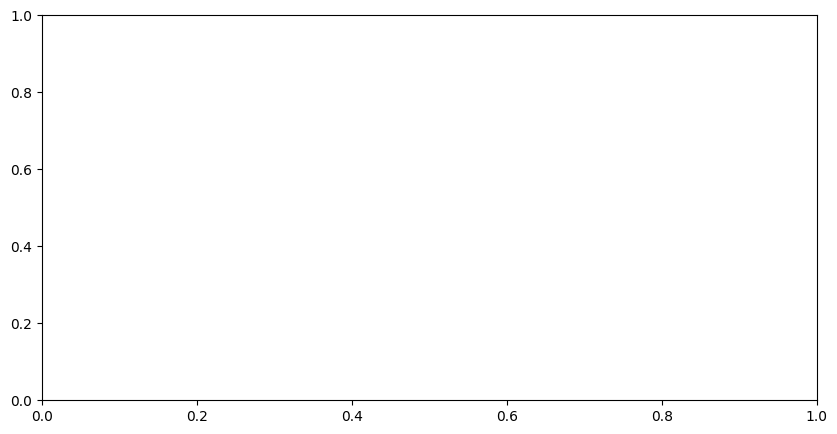

In [20]:
import matplotlib.pyplot as plt
# Load the metrics CSV
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
print(metrics.head(20))
# Extract training and validation loss
train_loss = metrics['train_loss_step'].dropna()
val_loss = metrics['val_RMSE'].dropna()
# print("train_loss", train_loss)
print("val_loss", val_loss)
print("val_MAE", metrics['val_MAE'].dropna())
epochs = range(1, len(val_loss) + 1)
train_loss = train_loss[:len(val_loss)]
# Plot losses
plt.figure(figsize=(10, 5))
# plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Train Loss")
# plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [23]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = DeepAR.load_from_checkpoint(best_model_path)

c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [45]:
from pytorch_forecasting.metrics import MAE, RMSE
predictions = best_model.predict(val_loader, trainer_kwargs=dict(accelerator="cpu"), return_y=True)
print("MAE", MAE()(predictions.output, predictions.y))
print("RMSE", RMSE()(predictions.output, predictions.y))

MAE tensor(10.3713)
RMSE tensor(13.8283)


In [46]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE
print("y", len(predictions.y[0]))
print("output", len(predictions.output))
mse = mean_squared_error(predictions.y[0], predictions.output)
print("MSE", mse)

# Calculate R^2
r2 = r2_score(predictions.y[0], predictions.output)
print("R^2", r2)

y 24470
output 24470
MSE 191.22269
R^2 0.7018811841159072


## Visualization

In [24]:
raw_predictions = best_model.predict(
    val_loader, mode="raw", return_x=True, n_samples=100, trainer_kwargs=dict(accelerator="cpu"), return_y=True
)
# raw_predictions.output.prediction length is 24470, which is the number of data points in the validation set
# raw_predictions.output.prediction[0][0] length is 100, which is the number of samples

c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


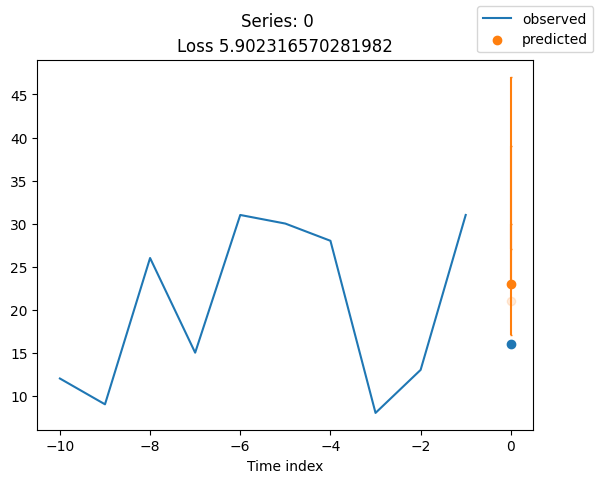

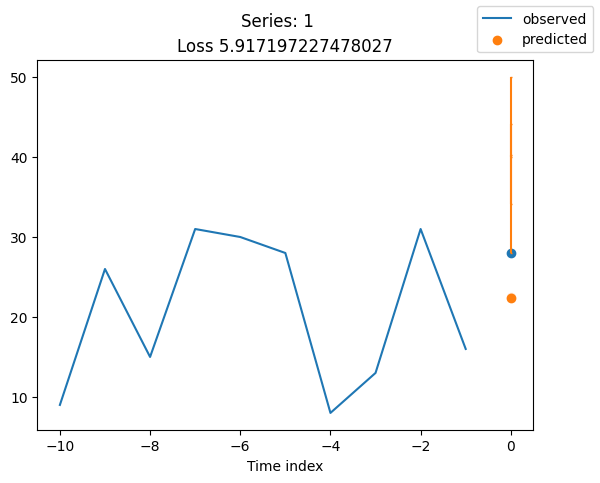

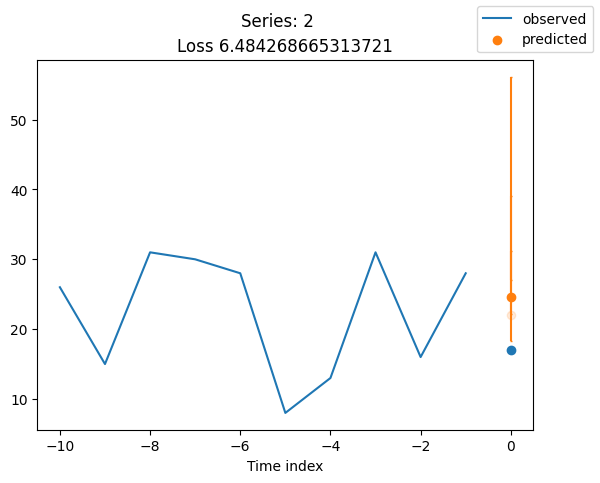

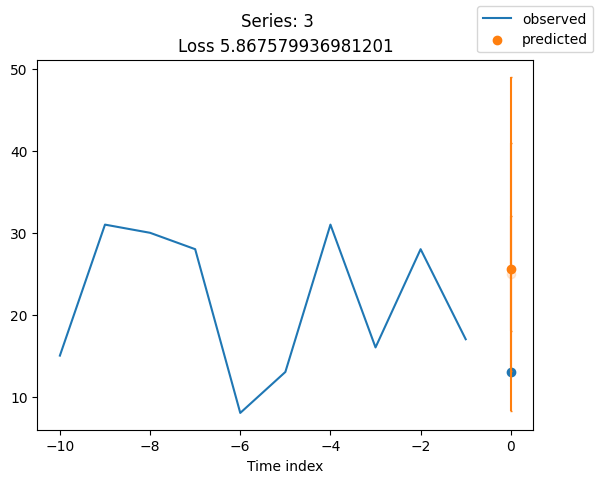

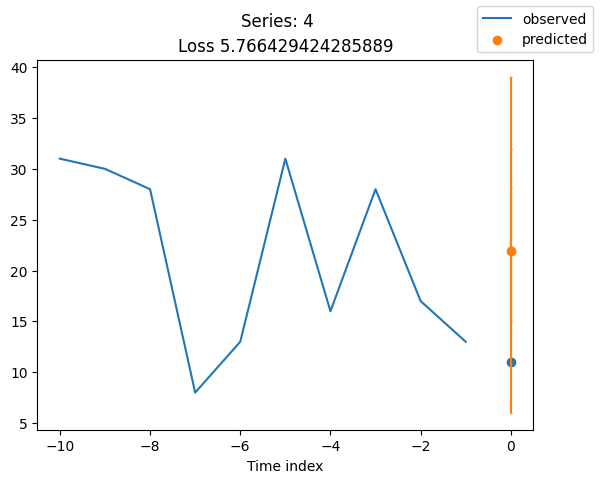

In [78]:
for idx in range(5):  # plot 10 examples
    best_model.plot_prediction(raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True)
    plt.suptitle(f"Series: {idx}")


In [68]:
print(raw_predictions.keys())
print(raw_predictions.x.keys())
print("x", raw_predictions.x['encoder_target'].shape)
print("gt", raw_predictions.x['decoder_target'].shape)
print("gt", raw_predictions.y[0].size())
print("time_idx", raw_predictions.x['decoder_time_idx'].shape)
print(raw_predictions.output.prediction.shape)

('output', 'x', 'index', 'decoder_lengths', 'y')
dict_keys(['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale'])
x torch.Size([24470, 10])
gt torch.Size([24470, 1])
gt torch.Size([24470, 1])
time_idx torch.Size([24470, 1])
torch.Size([24470, 1, 100])


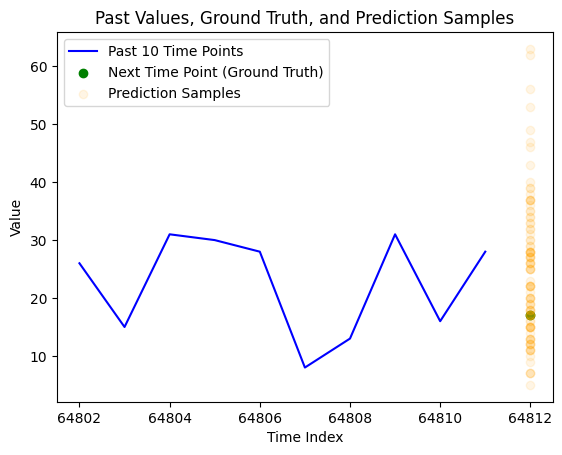

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# for sample_index in range(0, 5):
sample_index=2
# Define time_idx for past and future
decoder_time_idx = raw_predictions.x['decoder_time_idx'][sample_index]  # Future time index (single point)
# decoder_time_idx -10 ~ -1 is encoder_time_idx
encoder_time_idx = np.arange(decoder_time_idx - 10, decoder_time_idx)  # Past time index (10 points)


# Plot past 10 time points
plt.plot(encoder_time_idx, raw_predictions.x['encoder_target'][sample_index], label="Past 10 Time Points", color="blue")

# Plot the ground truth for the next time point
plt.scatter(decoder_time_idx, raw_predictions.x['decoder_target'][sample_index], label="Next Time Point (Ground Truth)", color="green")

# Plot the prediction samples for the next time point
for i, prediction_sample in enumerate(raw_predictions.output.prediction[sample_index][0]):
    plt.scatter(decoder_time_idx, prediction_sample, color="orange", alpha=0.1, label="Prediction Samples" if i == 0 else "")  # Add label once

# Add labels and legend
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.title("Past Values, Ground Truth, and Prediction Samples")
plt.legend()
plt.show()


In [80]:
quantile_predictions = best_model.predict(
    val_loader, mode="quantiles", return_x=True, n_samples=100, trainer_kwargs=dict(accelerator="cpu"), return_y=True
)
"""
Produce 7 quantiles:
0.1 (10th percentile)
0.2 (20th percentile)
0.3 (30th percentile)
0.5 (50th percentile or median)
0.7 (70th percentile)
0.8 (80th percentile)
0.9 (9pth percentile)
"""

c:\Users\sslin\miniconda3\envs\15712_project\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [86]:
print(quantile_predictions.x['decoder_target'].shape)
quantile_predictions.output.shape

torch.Size([24470, 1])


torch.Size([24470, 1, 7])

In [88]:
print(quantile_predictions.x['decoder_target'][0])
quantile_predictions[0][0]

tensor([16.])


tensor([[ 5.9800,  9.9000, 14.0000, 19.0000, 26.0000, 32.0000, 53.1000]])

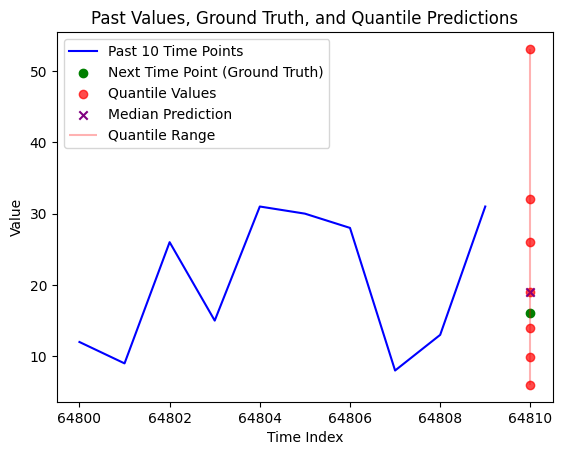

In [96]:
import matplotlib.pyplot as plt

sample_index = 0  # Adjust sample index as needed

# Define time_idx for past and future
decoder_time_idx = quantile_predictions.x['decoder_time_idx'][sample_index]  # Future time index (single point)
encoder_time_idx = np.arange(decoder_time_idx - 10, decoder_time_idx)  # Past time index (10 points)

# Extract quantile values (assuming sorted order from low to high quantiles)
quantiles = quantile_predictions.output[sample_index][0]  # shape: (7,)
low_quantile = quantiles[0]    # minimum quantile (e.g., 0.05 or similar)
high_quantile = quantiles[-1]  # maximum quantile (e.g., 0.95 or similar)
median_quantile = quantiles[len(quantiles) // 2]  # middle quantile (e.g., 0.5 or median)

# Plot past 10 time points
plt.plot(encoder_time_idx, quantile_predictions.x['encoder_target'][sample_index], label="Past 10 Time Points", color="blue")

# Plot the ground truth for the next time point
plt.scatter(decoder_time_idx, quantile_predictions.x['decoder_target'][sample_index], label="Next Time Point (Ground Truth)", color="green")

# Plot the quantiles for the next time point
plt.scatter([decoder_time_idx] * len(quantiles), quantiles, color="red", alpha=0.7, label="Quantile Values")
plt.scatter(decoder_time_idx, median_quantile, color="purple", label="Median Prediction", marker="x")
# Plot a vertical line to show the quantile range
plt.vlines(decoder_time_idx, low_quantile, high_quantile, color="red", alpha=0.3, label="Quantile Range")

# Add labels and legend
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.title("Past Values, Ground Truth, and Quantile Predictions")
plt.legend()
plt.show()


100%|██████████| 1001/1001 [00:00<00:00, 1221.94it/s]


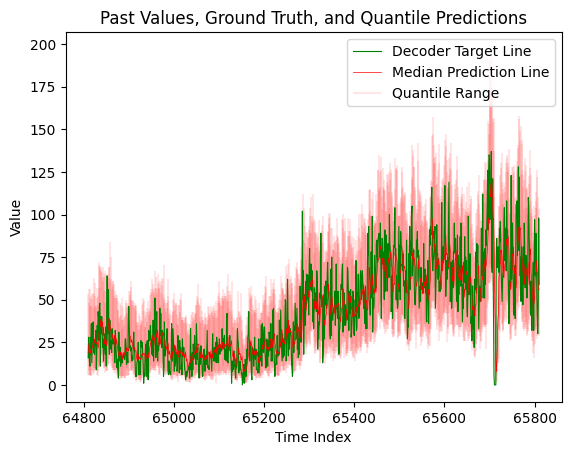

In [123]:
import matplotlib.pyplot as plt
from tqdm import tqdm
# Define time_idx for past and future
decoder_time_idx = quantile_predictions.x['decoder_time_idx'][0]  # Future time index (single point)
encoder_time_idx = np.arange(decoder_time_idx - 10, decoder_time_idx)  # Past time index (10 points)
# plt.plot(encoder_time_idx, quantile_predictions.x['encoder_target'][0], label="Past 10 Time Points", color="blue")
time_points = []
decoder_targets = []
median_quantiles = []

output_len = 1000
for i, time_point in tqdm(enumerate(quantile_predictions.x['decoder_time_idx']), total=output_len+1):
    if i>output_len:
        break
    # Quantile predictions for the current decoder time point
    quantiles = quantile_predictions.output[i][0]  # shape: (7,)
    low_quantile = quantiles[0]       # minimum quantile (e.g., 0.05)
    high_quantile = quantiles[-1]     # maximum quantile (e.g., 0.95)
    median_quantile = quantiles[len(quantiles) // 2]  # middle quantile (e.g., 0.5)
    time_points.append(time_point)
    decoder_targets.append(quantile_predictions.x['decoder_target'][i])
    median_quantiles.append(median_quantile)

    # plt.scatter(time_point, quantile_predictions.x['decoder_target'][i], color="green", s=1)
    # # Plot each prediction point and quantiles
    # plt.scatter(time_point, median_quantile, color="red", marker="." ,s=1, label="Median Prediction" if i == 0 else "")
    plt.vlines(time_point, low_quantile, high_quantile, color="red", alpha=0.1, label="Quantile Range" if i == 0 else "")
plt.plot(time_points, decoder_targets, color="green", linewidth=0.8, label="Decoder Target Line")
plt.plot(time_points, median_quantiles, color="red", linewidth=0.5, label="Median Prediction Line")
# Add labels and legend
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.title("Past Values, Ground Truth, and Quantile Predictions")
plt.legend()
plt.show()


In [100]:
print(quantile_predictions.x['encoder_target'][0])
print(quantile_predictions.x['encoder_target'][1])
print()
print(quantile_predictions.x['decoder_time_idx'][0])
print(quantile_predictions.x['decoder_time_idx'][1])

tensor([12.,  9., 26., 15., 31., 30., 28.,  8., 13., 31.])
tensor([ 9., 26., 15., 31., 30., 28.,  8., 13., 31., 16.])

tensor([64810])
tensor([64811])


In [1]:
# show matplotlib version
import matplotlib
print(matplotlib.__version__)

3.4.3


In [2]:
#matplotlob 3.4.3

^C


# Prophet
Can show trend of day and week.
##### Performance:
- MAE: 14.042
- RMSE 17.9
- MSE 324.70341174577493


In [70]:
# Reset the index and rename it to 'timestamp'
train_data = train_data.reset_index().rename(columns={'index': 'timestamp'})
test_data = test_data.reset_index().rename(columns={'index': 'timestamp'})

In [71]:
#rename timestamp to ds, request_count to y
train_data = train_data.rename(columns={'timestamp': 'ds', 'request_count': 'y'})
test_data = test_data.rename(columns={'timestamp': 'ds', 'request_count': 'y'})
test_input = test_data.copy()
test_input = test_input.drop(columns=['y'])

In [93]:
print(len(test_data))

24480


In [105]:
from prophet import Prophet
m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False, seasonality_mode='additive')
m.fit(train_data)

16:21:03 - cmdstanpy - INFO - Chain [1] start processing
16:21:44 - cmdstanpy - INFO - Chain [1] done processing


In [106]:
total_ds = m.make_future_dataframe(periods=24480, freq='T') 

In [107]:
total_forecast = m.predict(total_ds)

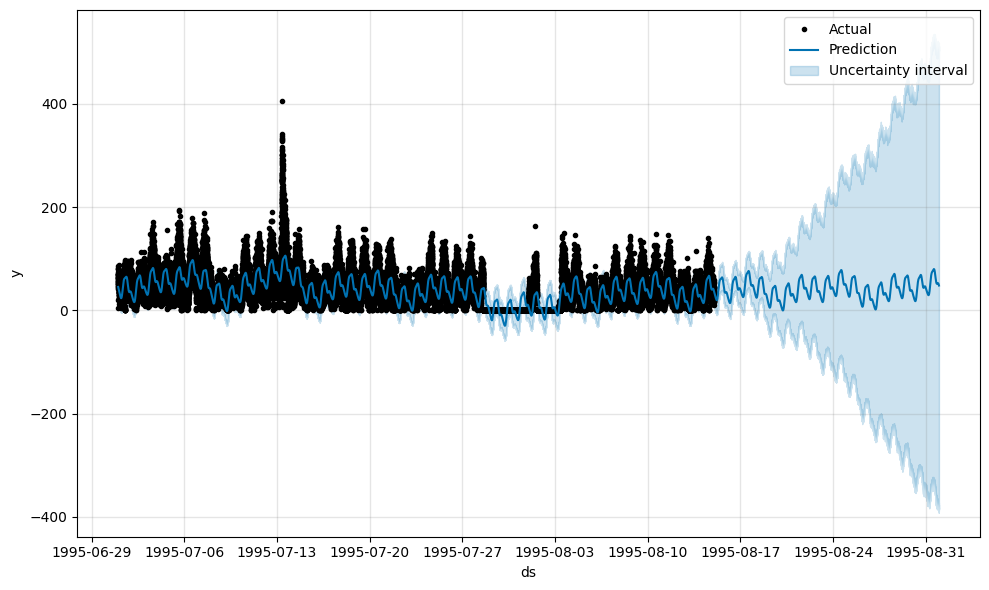

In [108]:
fig = m.plot(total_forecast)
plt.legend(['Actual', 'Prediction', 'Uncertainty interval'])
plt.show()

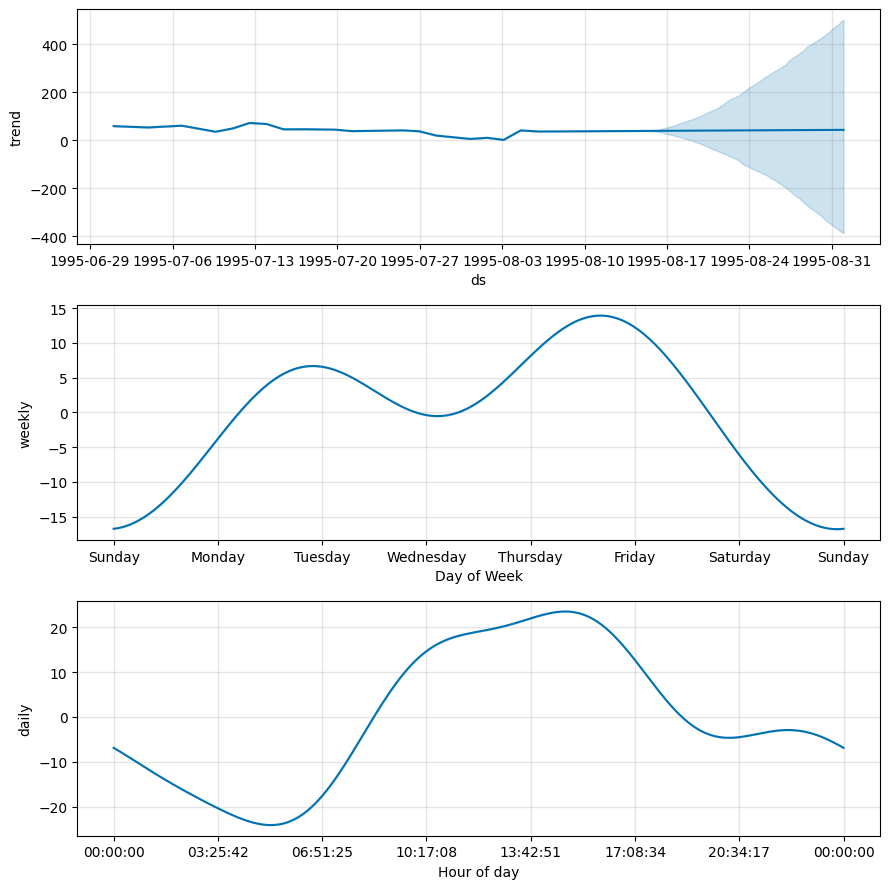

In [109]:
#plot components
fig = m.plot_components(total_forecast)
plt.show()

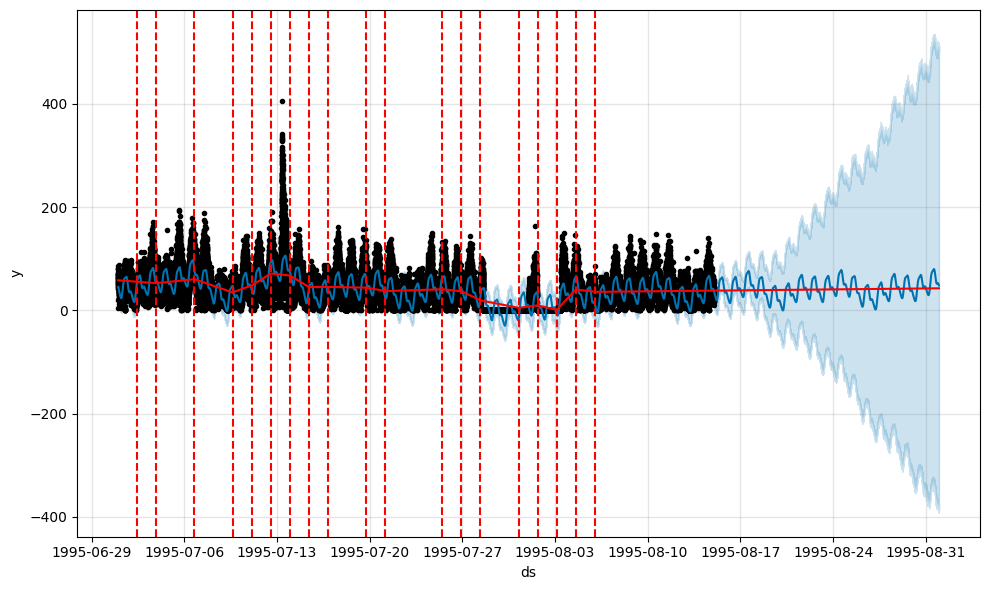

In [110]:
from prophet.plot import add_changepoints_to_plot
fig = m.plot(total_forecast)
a = add_changepoints_to_plot(fig.gca(), m, total_forecast)


In [111]:
# Only predict the test data
forecast = m.predict(test_input)

In [112]:
from sklearn.metrics import mean_absolute_error
y_true = test_data['y'].values
y_pred = forecast['yhat'].values
mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

from sklearn.metrics import mean_squared_error
from math import sqrt
mse = mean_squared_error(y_true, y_pred)
rmse = sqrt(mse)
print('RMSE: %.3f' % rmse)
print('MSE', mse)
"""MAE: 14.042
RMSE: 18.020
MSE 324.70341174577493"""


MAE: 14.042
RMSE: 18.020
MSE 324.70341174577493


'MAE: 14.042\nRMSE: 18.020\nMSE 324.70341174577493'

In [ ]:
from sklearn.model_selection import ParameterGrid
param_grid = {'seasonality_mode': ["additive", 'multiplicative'],
              'seasonality_prior_scale': [1, 5, 10, 20],
              'holidays_prior_scale': [5, 10, 20, 25],
              'changepoint_prior_scale': [0.005, 0.01, 0.05, 0.1]}
grid = ParameterGrid(param_grid)
#Store the results
rmse = []
#Loop
for params in grid:
    #model
    m = Prophet(seasonality_mode = params['seasonality_mode'],
                seasonality_prior_scale = params['seasonality_prior_scale'],
                holidays_prior_scale = params['holidays_prior_scale'],
                changepoint_prior_scale = params['changepoint_prior_scale'])
    m.fit(train_data)
    forecast = m.predict(test_input)

    y_true = test_data['y'].values
    y_pred = forecast['yhat'].values

    from sklearn.metrics import mean_squared_error
    from math import sqrt
    mse = mean_squared_error(y_true, y_pred)
    error = sqrt(mse)
    rmse.append(error)

In [116]:
tuning_results = pd.DataFrame(grid)
tuning_results['rmse'] = rmse
best_params = tuning_results[tuning_results.rmse == tuning_results.rmse.min()].transpose()
best_params

,34,42,50,58
changepoint_prior_scale,0.01,0.01,0.01,0.01
holidays_prior_scale,5,10,20,25
seasonality_mode,additive,additive,additive,additive
seasonality_prior_scale,10,10,10,10
rmse,17.999129,17.999129,17.999129,17.999129


# TCN
##### Performance
- MSE: 185

In [124]:
#The TCN expects input tensors of shape (N, Cin, L), where N, Cin, L denote the batch size, number of input channels and the sequence length
import numpy as np

train_data = train_data.values.reshape(-1)
test_data = test_data.values.reshape(-1)


# Creating input and output sequences for supervised learning (windowed data)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys).reshape(-1, 1)

seq_length = 10
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")


Training data shape: (64790, 1, 10), (64790, 1)
Testing data shape: (24470, 1, 10), (24470, 1)


In [127]:
import torch
import torch.nn as nn
from nbeats_pytorch.model import NBeatsNet
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 2048
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [170]:
import torch
import torch.nn as nn
from pytorch_tcn import TCN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define TCN model
num_inputs = 1  # Since request count is univariate
seq_length = 10  # Input sequence length (10-minute intervals)
num_channels = [16,32, 64, 10]  # Define your TCN layers here
kernel_size = 4
dropout = 0.1

# Initialize TCN model
tcn_model = TCN(
    num_inputs=num_inputs,
    num_channels=num_channels,
    kernel_size=kernel_size,
    dropout=dropout,
    causal=False,
    output_projection=1
).to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(tcn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-7)


In [171]:

# Training loop
epochs = 200
best_test_loss = 185
for epoch in range(epochs):
    tcn_model.train()  # Set model to training mode

    # Training phase
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        forecast = tcn_model(x_batch)[:,:, 0]
        # print(forecast.shape)
        loss = criterion(forecast, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Evaluation phase
    tcn_model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            forecast = tcn_model(x_batch)[:,:, 0]
            loss = criterion(forecast, y_batch)

            test_loss += loss.item() * x_batch.size(0)

    test_loss /= len(test_loader.dataset)
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(tcn_model.state_dict(), 'best_tcn_model.pth')

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Epoch 1/200, Train Loss: 481.2008, Test Loss: 229.6898
Epoch 2/200, Train Loss: 245.7278, Test Loss: 210.1419
Epoch 3/200, Train Loss: 224.5986, Test Loss: 204.5886
Epoch 4/200, Train Loss: 214.1973, Test Loss: 201.8824
Epoch 5/200, Train Loss: 210.3974, Test Loss: 195.2324
Epoch 6/200, Train Loss: 207.9965, Test Loss: 190.7205
Epoch 7/200, Train Loss: 207.4213, Test Loss: 195.4707
Epoch 8/200, Train Loss: 206.5177, Test Loss: 196.1115
Epoch 9/200, Train Loss: 204.3848, Test Loss: 191.2945
Epoch 10/200, Train Loss: 203.6843, Test Loss: 189.1803
Epoch 11/200, Train Loss: 204.6104, Test Loss: 193.5122
Epoch 12/200, Train Loss: 203.9050, Test Loss: 196.6724
Epoch 13/200, Train Loss: 202.4583, Test Loss: 186.3961
Epoch 14/200, Train Loss: 202.9977, Test Loss: 198.3546
Epoch 15/200, Train Loss: 203.1282, Test Loss: 187.5975
Epoch 16/200, Train Loss: 201.7037, Test Loss: 195.6089
Epoch 17/200, Train Loss: 201.1619, Test Loss: 190.7839
Epoch 18/200, Train Loss: 200.4708, Test Loss: 187.9192
E

In [172]:
# Training loop
epochs = 200
best_test_loss = 185
for epoch in range(epochs):
    tcn_model.train()  # Set model to training mode

    # Training phase
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        forecast = tcn_model(x_batch)[:,:, 0]
        # print(forecast.shape)
        loss = criterion(forecast, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Evaluation phase
    tcn_model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            forecast = tcn_model(x_batch)[:,:, 0]
            loss = criterion(forecast, y_batch)

            test_loss += loss.item() * x_batch.size(0)

    test_loss /= len(test_loader.dataset)
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(tcn_model.state_dict(), 'best_tcn_model.pth')

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch 1/200, Train Loss: 191.5620, Test Loss: 187.2414
Epoch 2/200, Train Loss: 190.3935, Test Loss: 188.4674
Epoch 3/200, Train Loss: 190.7553, Test Loss: 186.7834
Epoch 4/200, Train Loss: 191.3835, Test Loss: 186.4721
Epoch 5/200, Train Loss: 191.4446, Test Loss: 188.3435
Epoch 6/200, Train Loss: 191.5057, Test Loss: 186.4469
Epoch 7/200, Train Loss: 191.1556, Test Loss: 189.3158
Epoch 8/200, Train Loss: 191.6940, Test Loss: 185.7184
Epoch 9/200, Train Loss: 190.8305, Test Loss: 187.2058
Epoch 10/200, Train Loss: 191.8912, Test Loss: 186.8131
Epoch 11/200, Train Loss: 191.2247, Test Loss: 188.4865
Epoch 12/200, Train Loss: 190.8079, Test Loss: 186.2845
Epoch 13/200, Train Loss: 190.7220, Test Loss: 186.7443
Epoch 14/200, Train Loss: 191.3008, Test Loss: 189.1536
Epoch 15/200, Train Loss: 191.0345, Test Loss: 186.3547
Epoch 16/200, Train Loss: 190.9218, Test Loss: 186.1621
Epoch 17/200, Train Loss: 190.5927, Test Loss: 186.7677
Epoch 18/200, Train Loss: 191.2979, Test Loss: 190.7853
E

KeyboardInterrupt: 